# 05 - Prophet Model
**Goal**: Compare Facebook Prophet against LightGBM for 24h-ahead heat demand forecasting.

Prophet models trend + yearly/weekly/daily seasonality + holidays explicitly.
Weather variables are added as extra regressors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
%matplotlib inline

/Users/hervehuisman/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 1. Load Data

In [2]:
df = pd.read_csv('../data/processed/demand_with_weather.csv', index_col='timestamp', parse_dates=True)
df = df.dropna(subset=['heat_demand_mw'])
print(f'Loaded {len(df)} rows')

Loaded 43843 rows


## 2. Prepare Prophet Format
Prophet requires columns named `ds` (datetime) and `y` (target).

In [3]:
# Weather regressors to include
REGRESSORS = [
    'temperature_c', 'heating_degrees', 'wind_speed_ms',
    'solar_radiation_wm2', 'humidity_pct', 'snow_depth_m', 'cloud_cover_pct'
]

prophet_df = df[['heat_demand_mw'] + REGRESSORS].copy()
prophet_df = prophet_df.reset_index()
prophet_df.columns = ['ds', 'y'] + REGRESSORS
prophet_df = prophet_df.dropna()

# Train/test split
train = prophet_df[prophet_df['ds'].dt.year < 2024]
test  = prophet_df[prophet_df['ds'].dt.year == 2024]

print(f'Train: {len(train)} rows')
print(f'Test:  {len(test)} rows')

Train: 35060 rows
Test:  8783 rows


## 3. Build German Holiday Calendar for Prophet

In [4]:
import holidays as hol

de_holidays = hol.Germany(state='SH', years=range(2020, 2025))
holiday_df = pd.DataFrame([
    {'ds': pd.Timestamp(date), 'holiday': name}
    for date, name in de_holidays.items()
])
print(f'{len(holiday_df)} holiday entries')
holiday_df.head(8)

50 holiday entries


,ds,holiday
0,2020-01-01,New Year's Day
1,2020-04-10,Good Friday
2,2020-04-13,Easter Monday
3,2020-05-01,Labor Day
4,2020-05-21,Ascension Day
5,2020-06-01,Whit Monday
6,2020-10-03,German Unity Day
7,2020-12-25,Christmas Day


## 4. Train Prophet Model
**Note**: Prophet training takes 2-5 minutes on hourly data.

In [5]:
print('Training Prophet (this takes a few minutes)...')

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    holidays=holiday_df,
    seasonality_mode='multiplicative',  # better for data with varying amplitude
    changepoint_prior_scale=0.05
)

for reg in REGRESSORS:
    model.add_regressor(reg)

model.fit(train)
print('Done!')

Training Prophet (this takes a few minutes)...


00:01:11 - cmdstanpy - INFO - Chain [1] start processing
00:01:23 - cmdstanpy - INFO - Chain [1] done processing


Done!


## 5. Forecast on 2024 Test Set

In [6]:
# For 24h-ahead forecast we use the actual future weather (same assumption as LightGBM)
forecast = model.predict(test[['ds'] + REGRESSORS])

y_test   = test['y'].values
y_pred   = forecast['yhat'].values

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / np.clip(y_test, 1, None))) * 100

print(f'Prophet (2024 test set):')
print(f'  MAE:  {mae:.2f} MW')
print(f'  RMSE: {rmse:.2f} MW')
print(f'  MAPE: {mape:.1f}%')

Prophet (2024 test set):
  MAE:  16.88 MW
  RMSE: 21.16 MW
  MAPE: 18.4%


## 6. Prophet Component Plot
Shows trend, yearly seasonality, weekly seasonality, and holiday effects separately.

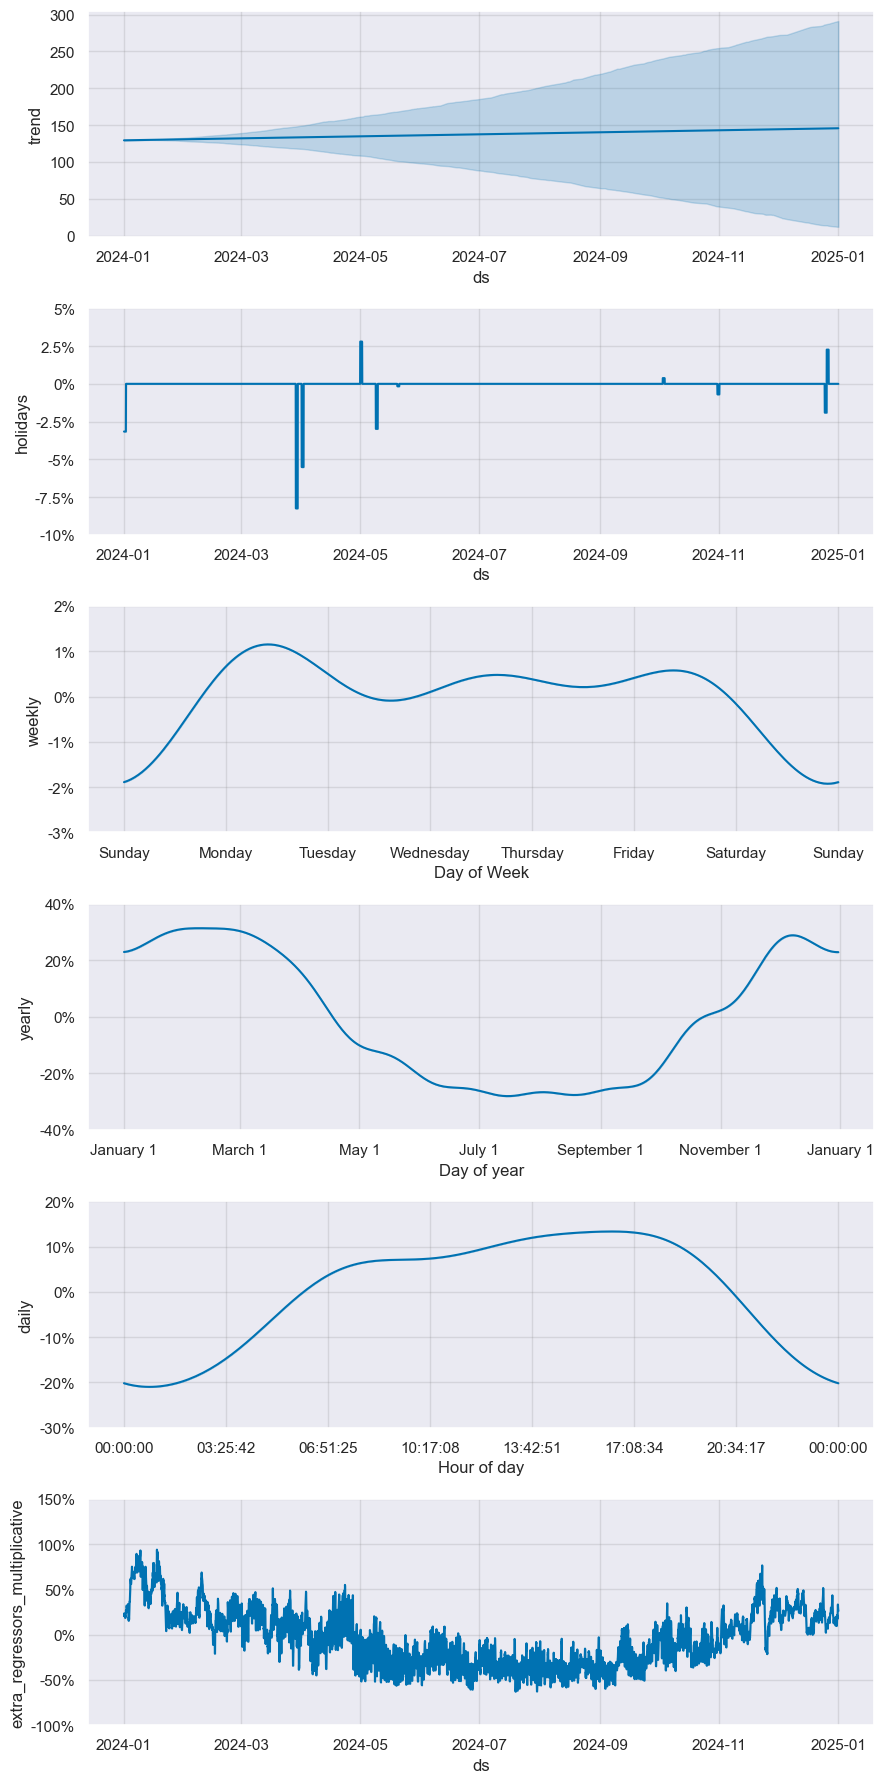

In [7]:
fig = model.plot_components(forecast)
plt.tight_layout()
plt.show()

## 7. Predicted vs Actual — Winter Week (Jan 2024)

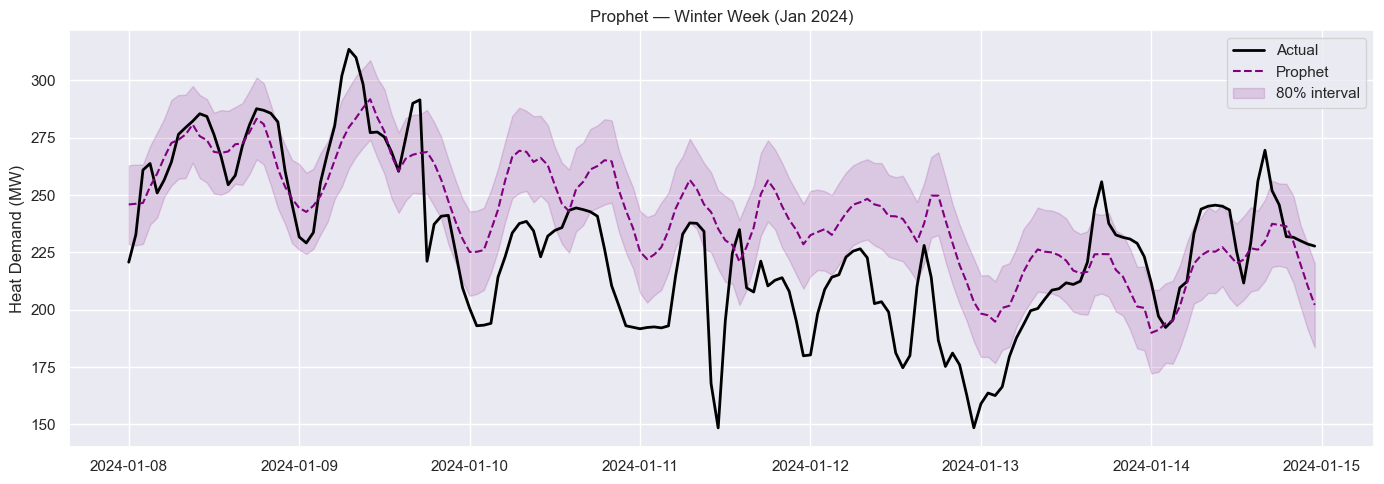

In [8]:
def plot_week(start, title):
    mask = (test['ds'] >= start) & (test['ds'] < pd.Timestamp(start) + pd.Timedelta(days=7))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test.loc[mask, 'ds'], test.loc[mask, 'y'], label='Actual', linewidth=2, color='black')
    ax.plot(forecast.loc[mask.values, 'ds'], forecast.loc[mask.values, 'yhat'],
            label='Prophet', linestyle='--', color='purple')
    ax.fill_between(forecast.loc[mask.values, 'ds'],
                    forecast.loc[mask.values, 'yhat_lower'],
                    forecast.loc[mask.values, 'yhat_upper'],
                    alpha=0.15, color='purple', label='80% interval')
    ax.set_title(title)
    ax.set_ylabel('Heat Demand (MW)')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_week('2024-01-08', 'Prophet — Winter Week (Jan 2024)')

## 8. Predicted vs Actual — Autumn Week (Oct 2024)

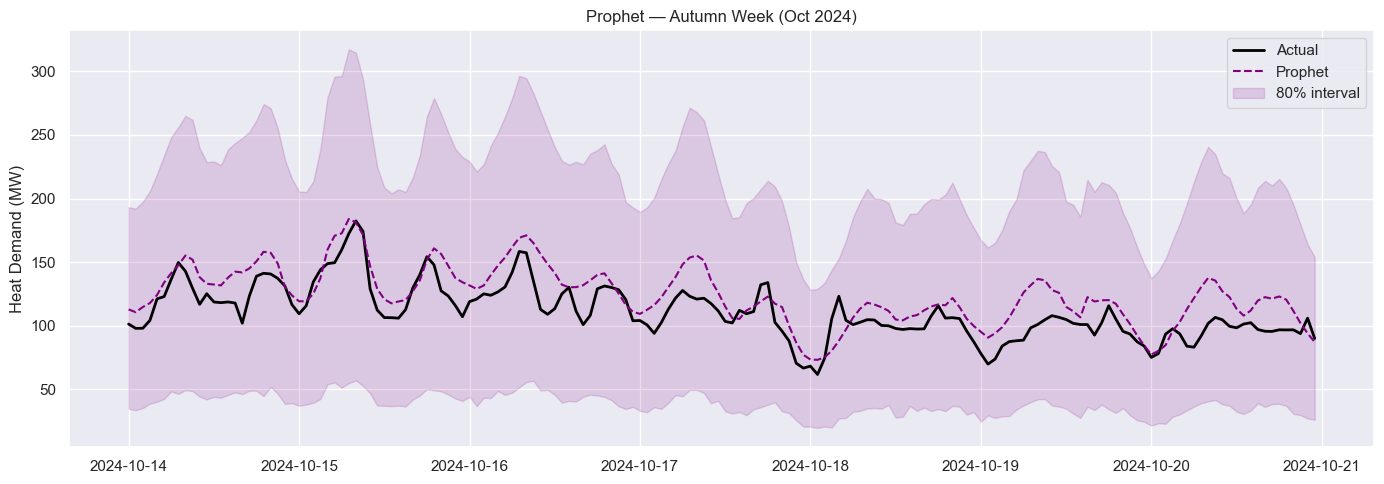

In [9]:
plot_week('2024-10-14', 'Prophet — Autumn Week (Oct 2024)')

## 9. Model Comparison Summary

                 MAE   RMSE  MAPE
model                            
Random Forest   9.67  14.06   8.6
LightGBM        8.61  12.62   7.8
Prophet        16.88  21.16  18.4


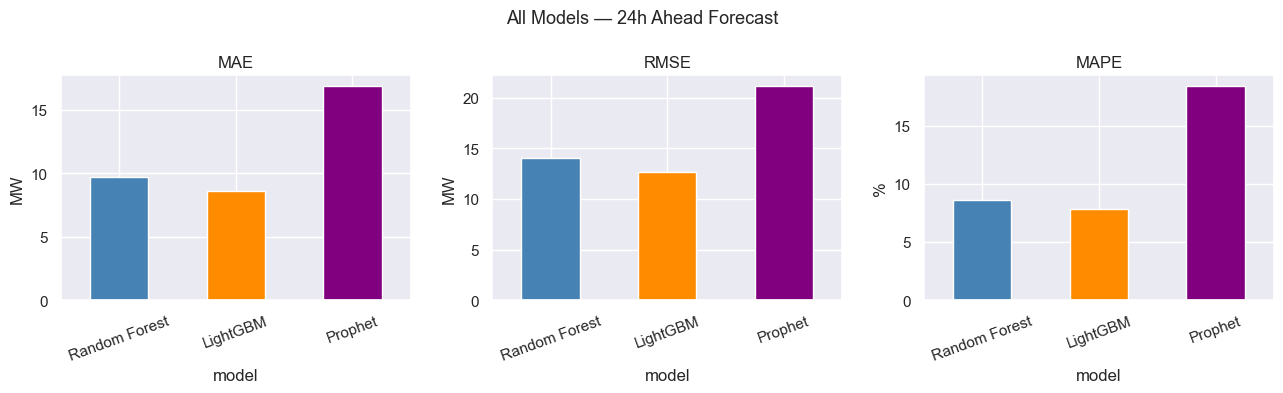

In [10]:
comparison = pd.DataFrame([
    {'model': 'Random Forest', 'MAE': 9.67, 'RMSE': 14.06, 'MAPE': 8.6},
    {'model': 'LightGBM',      'MAE': 8.61, 'RMSE': 12.62, 'MAPE': 7.8},
    {'model': 'Prophet',       'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE': round(mape,1)},
]).set_index('model')

print(comparison.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['steelblue', 'darkorange', 'purple']
for i, metric in enumerate(['MAE', 'RMSE', 'MAPE']):
    comparison[metric].plot(kind='bar', ax=axes[i], color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel('MW' if metric != 'MAPE' else '%')
    axes[i].tick_params(axis='x', rotation=20)
plt.suptitle('All Models — 24h Ahead Forecast', fontsize=13)
plt.tight_layout()
plt.show()